In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import plotly.express as px
import os
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

plt.style.use('seaborn-v0_8-whitegrid')

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
warnings.filterwarnings("ignore")

# EDA

In [2]:
path = "/kaggle/input/datasets/fedesoriano/heart-failure-prediction/heart.csv"
df = pd.read_csv(path)

## General

In [3]:
print("\n===== SHAPE, COLUMNS =====")
print("Shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())
print("\n===== HEAD =====")
print(df.head())

print("\n===== INFO =====")
print(df.info())


===== SHAPE, COLUMNS =====
Shape: (918, 12)

Columns:
 ['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS', 'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope', 'HeartDisease']

===== HEAD =====
   Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  MaxHR ExerciseAngina  Oldpeak ST_Slope  HeartDisease
0   40   M           ATA        140          289          0     Normal    172              N      0.0       Up             0
1   49   F           NAP        160          180          0     Normal    156              N      1.0     Flat             1
2   37   M           ATA        130          283          0         ST     98              N      0.0       Up             0
3   48   F           ASY        138          214          0     Normal    108              Y      1.5     Flat             1
4   54   M           NAP        150          195          0     Normal    122              N      0.0       Up             0

===== INFO =====
<clas

In [4]:
print("Duplicate rows:", df.duplicated().sum())
print("Missing values:")
print(df.isnull().sum())

Duplicate rows: 0
Missing values:
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64


In [5]:
int((df["RestingBP"] == 0).sum())

1

In [6]:
int((df['Cholesterol'] == 0).sum())

172

In [7]:
int(((df["Cholesterol"]== 0) | (df["RestingBP"] == 0)).sum())

172

In [8]:
print(df.describe(include='all'))

               Age  Sex ChestPainType   RestingBP  Cholesterol   FastingBS RestingECG       MaxHR ExerciseAngina     Oldpeak ST_Slope  HeartDisease
count   918.000000  918           918  918.000000   918.000000  918.000000        918  918.000000            918  918.000000      918    918.000000
unique         NaN    2             4         NaN          NaN         NaN          3         NaN              2         NaN        3           NaN
top            NaN    M           ASY         NaN          NaN         NaN     Normal         NaN              N         NaN     Flat           NaN
freq           NaN  725           496         NaN          NaN         NaN        552         NaN            547         NaN      460           NaN
mean     53.510893  NaN           NaN  132.396514   198.799564    0.233115        NaN  136.809368            NaN    0.887364      NaN      0.553377
std       9.432617  NaN           NaN   18.514154   109.384145    0.423046        NaN   25.460334            NaN

In [9]:
target = "HeartDisease"
num_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
cat_cols = ['Sex', 'ChestPainType', 'FastingBS', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

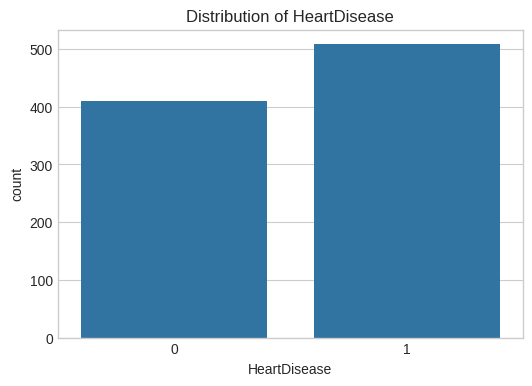

Target ratio:
HeartDisease
1    0.553377
0    0.446623
Name: proportion, dtype: float64


In [10]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x=target)
plt.title("Distribution of HeartDisease")
plt.show()

print("Target ratio:")
print(df[target].value_counts(normalize=True))

## Phân bố dữ liệu số

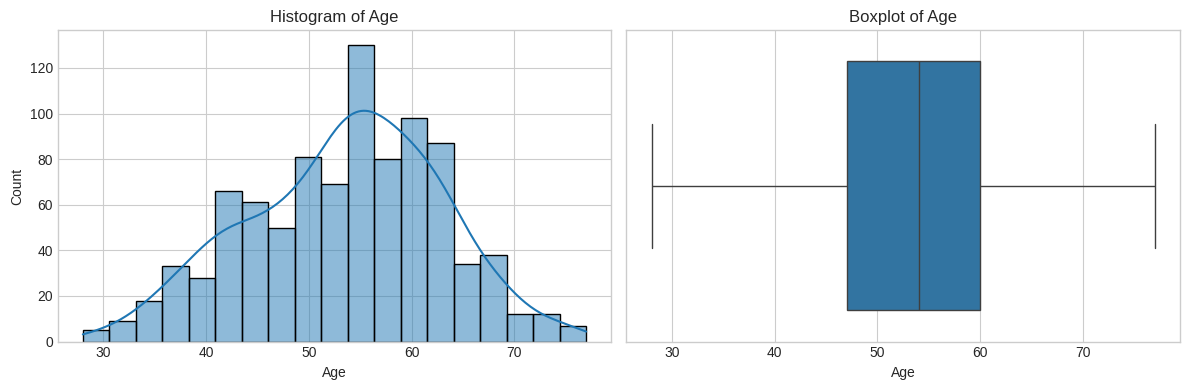

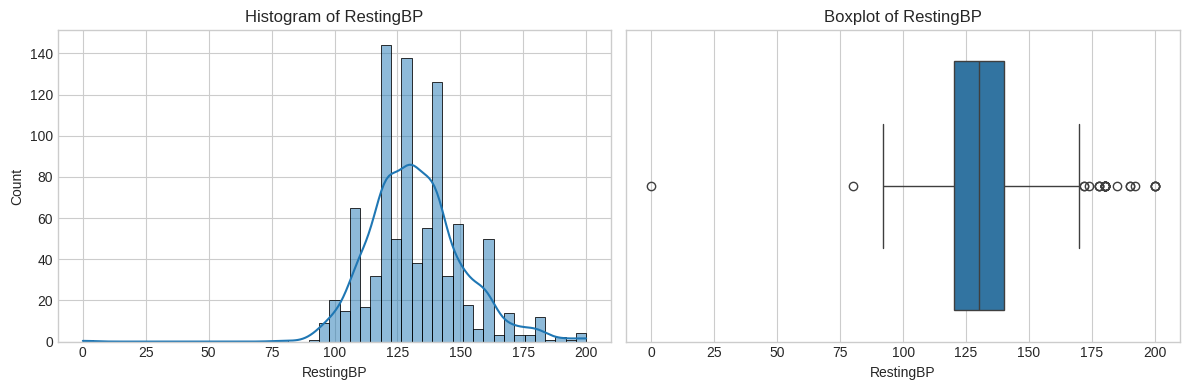

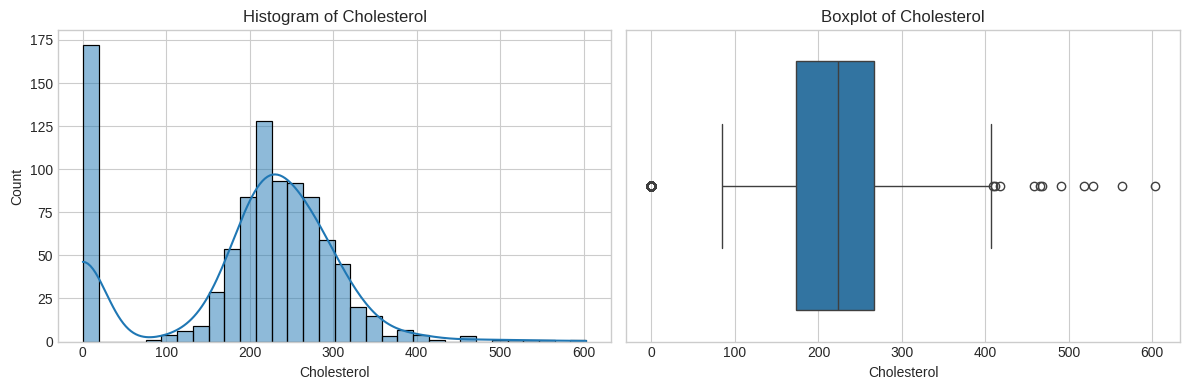

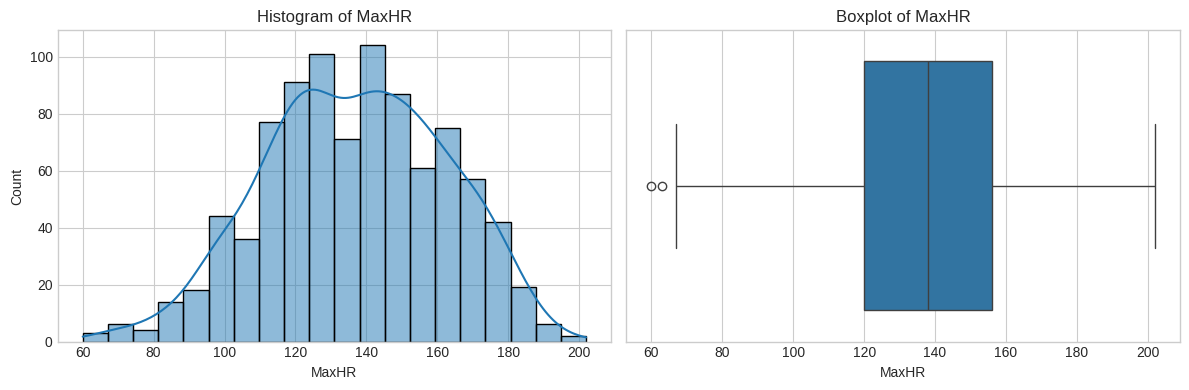

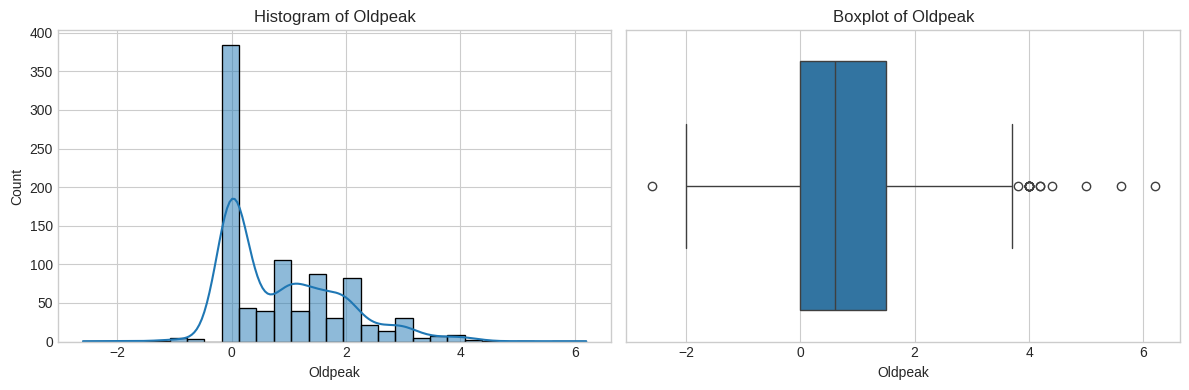

In [11]:
# Distribution of "num_cols" (Histogram, boxplot)
for col in num_cols:
    fig, axes = plt.subplots(1, 2, figsize=(12,4))
    
    sns.histplot(df[col], kde=True, ax=axes[0])
    axes[0].set_title(f"Histogram of {col}")
    
    sns.boxplot(x=df[col], ax=axes[1])
    axes[1].set_title(f"Boxplot of {col}")
    
    plt.tight_layout()
    plt.show()

In [12]:
print("Mean of numeric features by target:")
print(df.groupby(target)[num_cols].mean().round(2))

Mean of numeric features by target:
                Age  RestingBP  Cholesterol   MaxHR  Oldpeak
HeartDisease                                                
0             50.55     130.18       227.12  148.15     0.41
1             55.90     134.19       175.94  127.66     1.27


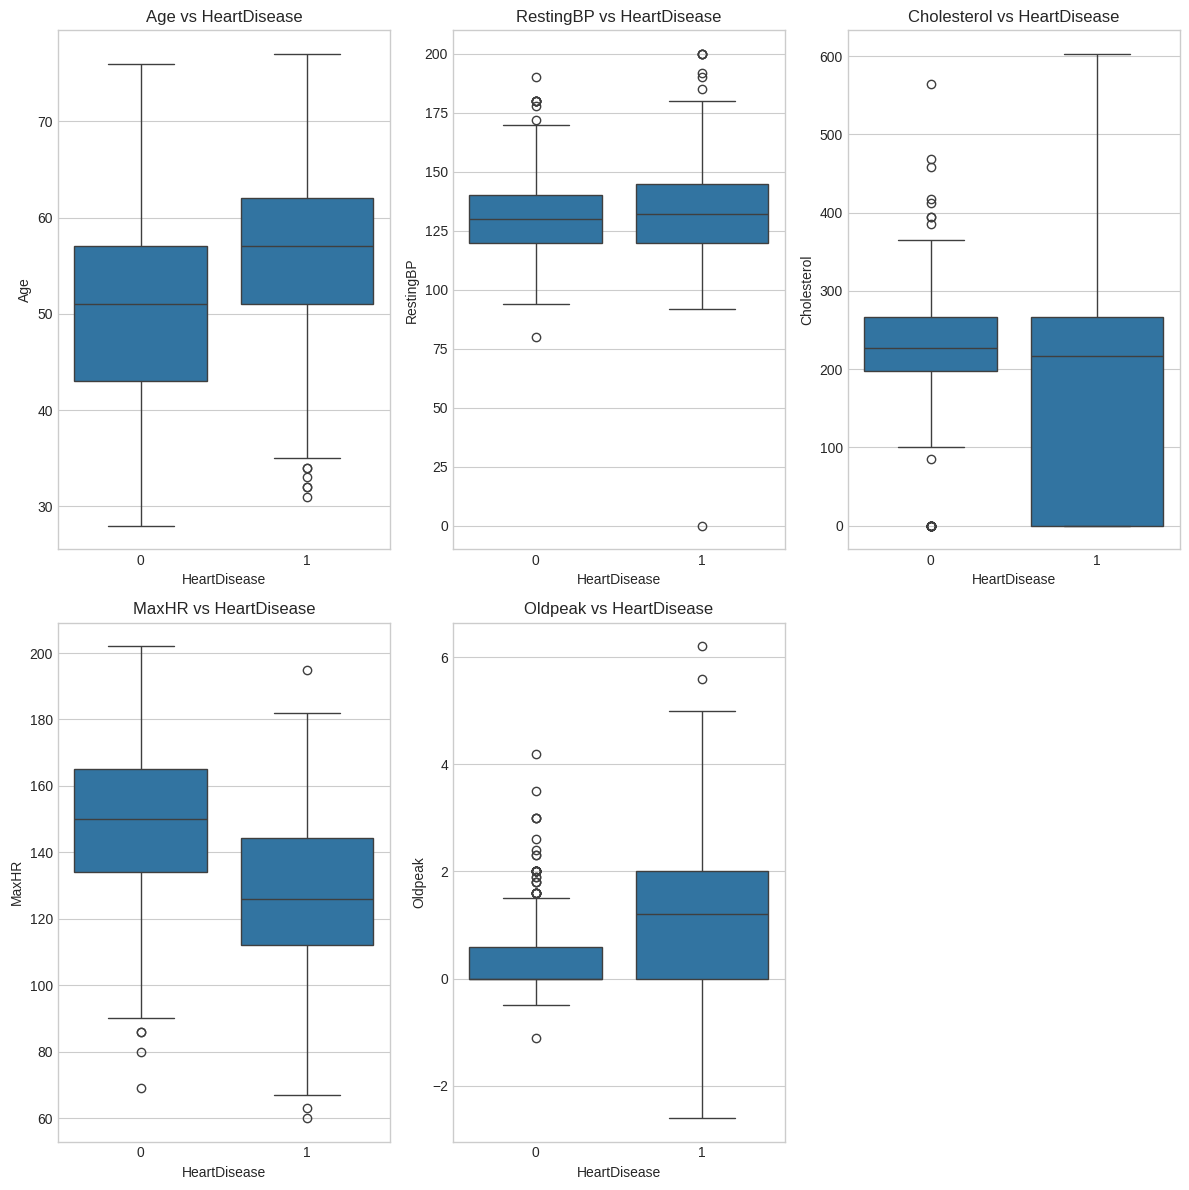

In [13]:
fig, axes = plt.subplots(2,3,figsize=(12,12))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.boxplot(data=df, x=target, y=col, ax=axes[i])
    axes[i].set_title(f"{col} vs {target}")

for j in range(len(num_cols), len(axes)):
    axes[j].axis('off')
    
plt.tight_layout()
plt.show()

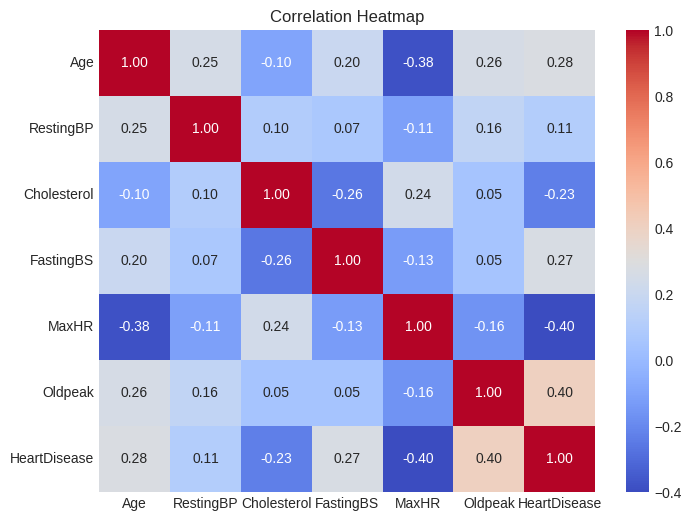

In [14]:
# Correlation heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()

## Phân bố dữ liệu phân loại

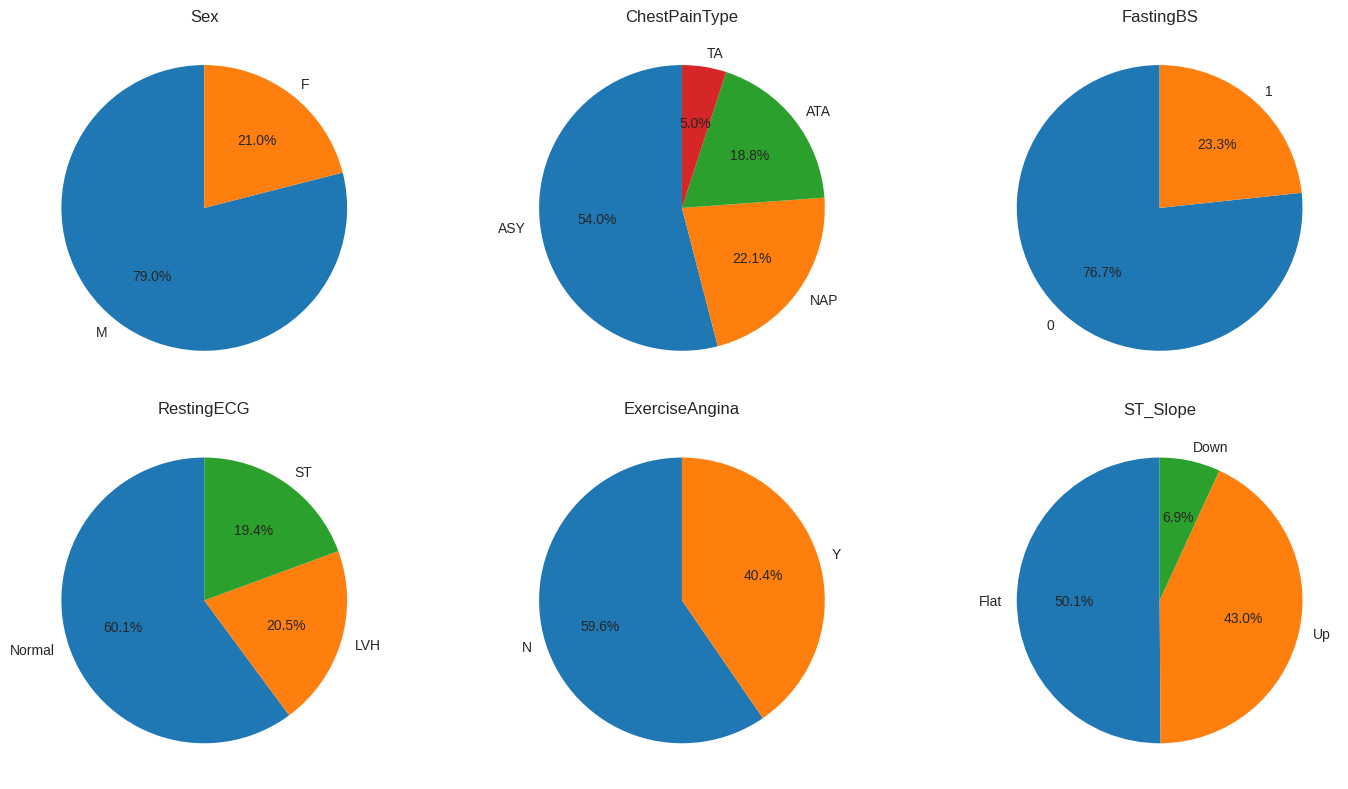

In [15]:
# Pie chart of "cat_cols"
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    counts = df[col].value_counts()

    axes[i].pie(
        counts.values,
        labels=counts.index,
        autopct='%1.1f%%',
        startangle=90
    )
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

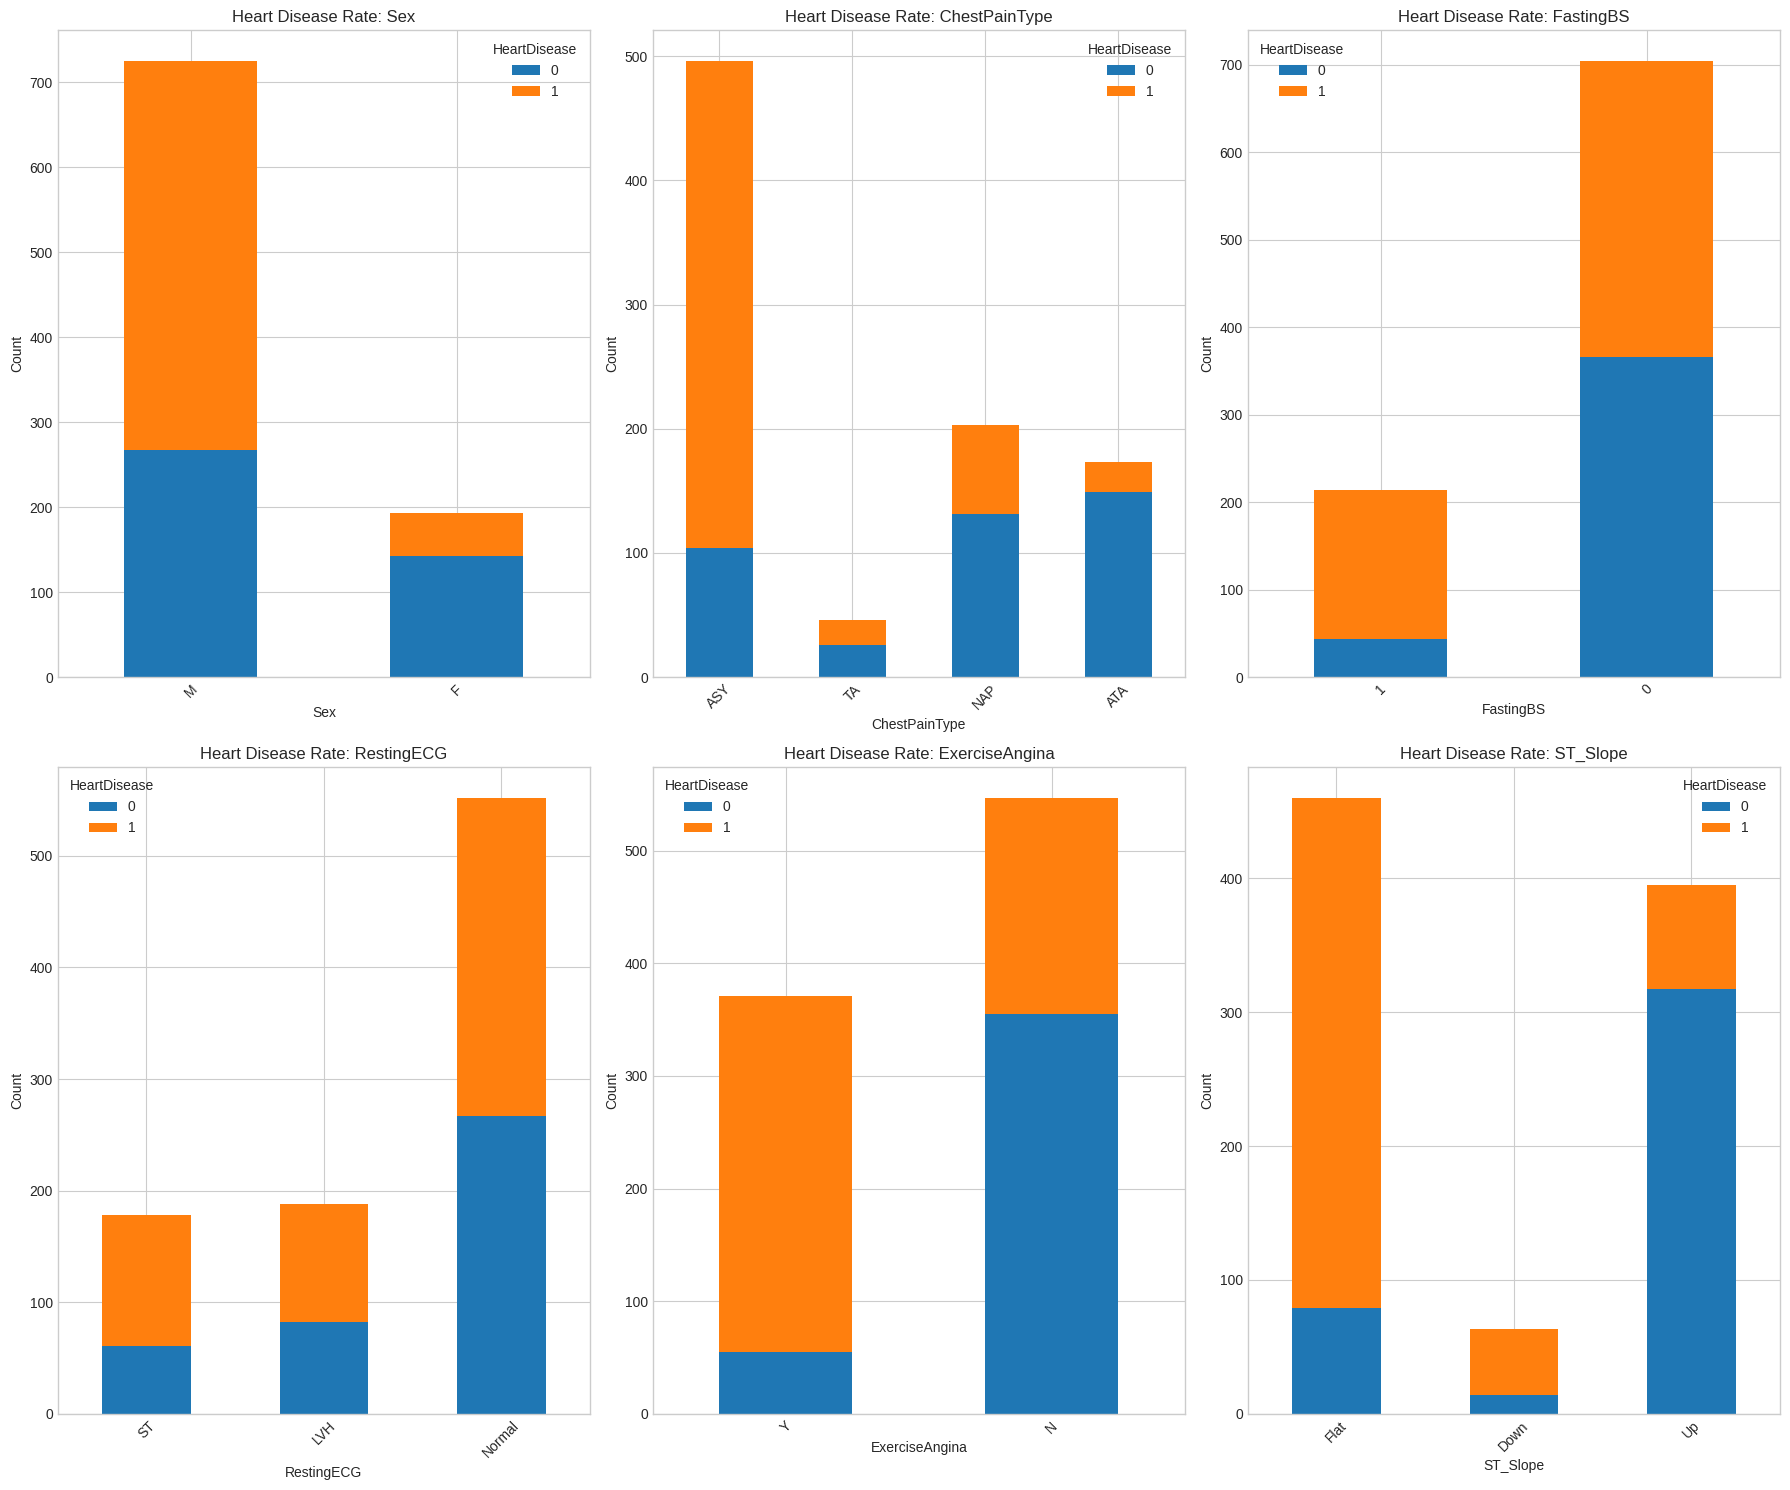

In [16]:
# Distribution of "cat_cols" sorted by the rate (percentage) of heart disease
fig, axes = plt.subplots(2, 3, figsize=(18, 15))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    cross_tab = pd.crosstab(df[col], df[target])
    rate = cross_tab[1] / cross_tab.sum(axis=1)
    sorted_index = rate.sort_values(ascending=False).index
    cross_tab_sorted = cross_tab.loc[sorted_index]
    cross_tab_sorted.plot(kind='bar', stacked=True, ax=axes[i])
    
    axes[i].set_title(f'Heart Disease Rate: {col}')
    axes[i].set_ylabel('Count')
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45)

plt.tight_layout()
plt.show()

# DATA PREPROCESSING

In [17]:
from sklearn.model_selection import train_test_split, cross_val_score, RepeatedStratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder, OrdinalEncoder, MinMaxScaler
from sklearn.impute import KNNImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, mean_absolute_error, roc_auc_score, RocCurveDisplay
from sklearn.compose import ColumnTransformer

In [18]:
def preprocess_final(df, test_size=0.2, random_state=42, iscale=True):
    # 1. Cleaning
    df_clean = df.copy()
    df_clean['Cholesterol'] = df_clean['Cholesterol'].replace(0, np.nan)
    df_clean['RestingBP'] = df_clean['RestingBP'].replace(0, np.nan)
    
    # 2. Split
    X = df_clean.drop('HeartDisease', axis=1)
    y = df_clean['HeartDisease']
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )
    
    # 3. Define Transformers
    numeric_features = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR']
    norm_numeric_features = ['Oldpeak']
    binary_features = ['FastingBS']
    nominal_features = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina']
    ordinal_features = ['ST_Slope']

    numeric_transformer = StandardScaler() if iscale else 'passthrough'
    norm_numeric_transformer = MinMaxScaler() if iscale else 'passthrough'
    
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, numeric_features),
            ('norm_num', norm_numeric_transformer, norm_numeric_features),
            ('bin', 'passthrough', binary_features),
            ('nom', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), nominal_features),
            ('ord', OrdinalEncoder(categories=[['Down', 'Flat', 'Up']]), ordinal_features),
        ],
        remainder='drop'
    )

    # 4. Transform
    X_train_processed = preprocessor.fit_transform(X_train)
    X_test_processed = preprocessor.transform(X_test)
    
    # 5. Get Feature Names Safely
    all_feature_names = preprocessor.get_feature_names_out()
    
    X_train_combined = pd.DataFrame(X_train_processed, columns=all_feature_names)
    X_test_combined = pd.DataFrame(X_test_processed, columns=all_feature_names)

    # 6. Impute
    imputer = KNNImputer(n_neighbors=5, weights='distance')
    X_train_imputed = imputer.fit_transform(X_train_combined)
    X_test_imputed = imputer.transform(X_test_combined)
    
    X_train_final = pd.DataFrame(X_train_imputed, columns=all_feature_names)
    X_test_final = pd.DataFrame(X_test_imputed, columns=all_feature_names)
    
    return X_train_final, X_test_final, y_train, y_test
X_train, X_test, y_train, y_test = preprocess_final(df,iscale = True)

   num__Age  num__RestingBP  num__Cholesterol  num__MaxHR  norm_num__Oldpeak  bin__FastingBS  nom__Sex_M  nom__ChestPainType_ATA  nom__ChestPainType_NAP  nom__ChestPainType_TA  nom__RestingECG_Normal  nom__RestingECG_ST  nom__ExerciseAngina_Y  ord__ST_Slope  HeartDisease
0  0.970012        0.339016         -0.495919   -0.324520           0.463415             1.0         1.0                     1.0                     0.0                    0.0                     0.0                 1.0                    1.0            1.0             1
1  0.122028       -1.266031         -0.546248    1.689837           0.365854             1.0         1.0                     1.0                     0.0                    0.0                     0.0                 1.0                    0.0            2.0             0
2  0.546020       -0.159102          1.534037   -0.247045           0.500000             1.0         0.0                     0.0                     0.0                    0.0         

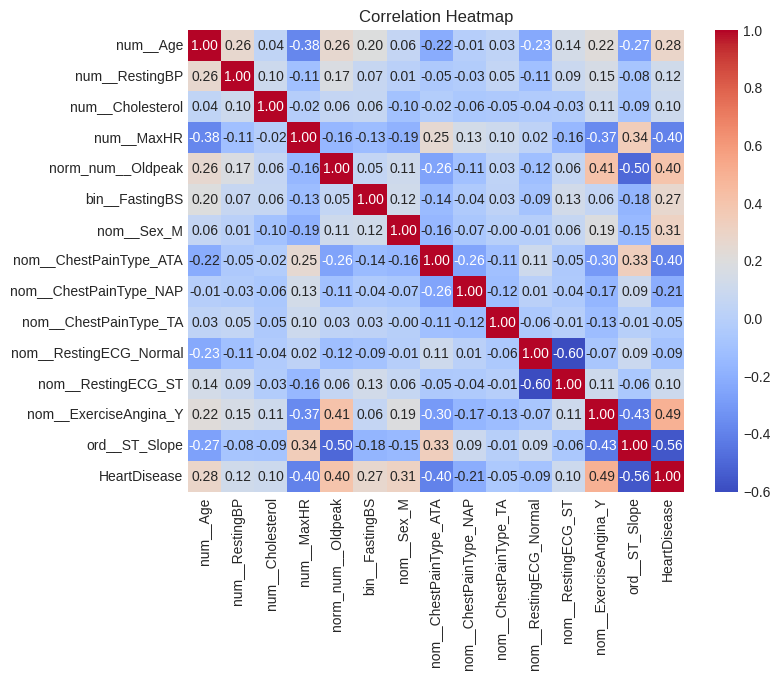

In [19]:
def plot_correlation_matrix(X_train, X_test, y_train, y_test):
    X_all = pd.concat([X_train, X_test], axis=0)
    y_all = pd.concat([pd.Series(y_train), pd.Series(y_test)], axis=0)
    full_df = pd.concat([X_all.reset_index(drop=True), 
                         y_all.reset_index(drop=True)], axis=1)
    full_df.columns = list(X_train.columns) + ['HeartDisease']
    print(full_df.head())
    plt.figure(figsize=(8,6))
    sns.heatmap(full_df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
    plt.title("Correlation Heatmap")
    plt.show()
plot_correlation_matrix(X_train, X_test, y_train, y_test)

# DATA PROCESSING

In [20]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC

In [21]:
def model_train(model):
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_test)
    
    print("Accuracy: {0:.4f}".format(accuracy_score(y_test, y_pred)))
    print("Precision: {0:.4f}".format(precision_score(y_test, y_pred)))
    print("Recall: {0:.4f}".format(recall_score(y_test, y_pred)))

    cv = RepeatedStratifiedKFold(n_splits = 10,n_repeats = 3,random_state = 1)
    print("Cross Validation Score : ",'{0:.4f}'.format(cross_val_score(model,X_train,y_train,cv = cv,scoring = 'roc_auc').mean()))
    print("ROC_AUC Score : ",'{0:.4f}'.format(roc_auc_score(y_test,y_pred)))
    RocCurveDisplay.from_estimator(model, X_test,y_test)
    plt.title('ROC_AUC_Plot')
    plt.show()

--- KNN ---
Accuracy: 0.8587
Precision: 0.8455
Recall: 0.9118
Cross Validation Score :  0.8816
ROC_AUC Score :  0.8522


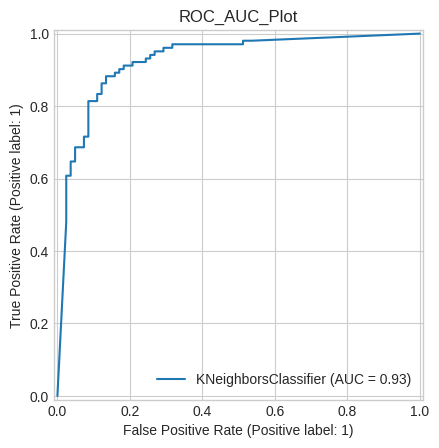

In [22]:
# Train KNN classifier
knn = KNeighborsClassifier(n_neighbors=5, weights='distance')
print("--- KNN ---")
model_train(knn)

--- RandomForest ---
Accuracy: 0.8696
Precision: 0.8900
Recall: 0.8725
Cross Validation Score :  0.9183
ROC_AUC Score :  0.8692


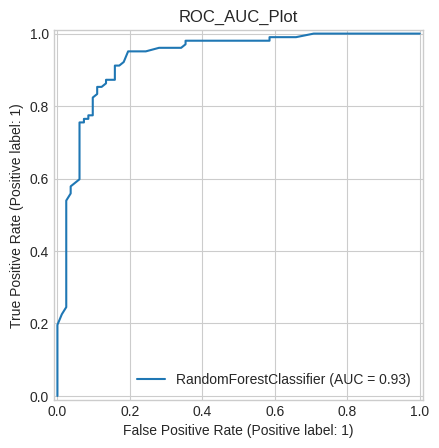

In [23]:
rf = RandomForestClassifier(n_estimators=120, random_state=42)
print("--- RandomForest ---")
model_train(rf)

--- MLP ---
Accuracy: 0.7880
Precision: 0.8119
Recall: 0.8039
Cross Validation Score :  0.8711
ROC_AUC Score :  0.7861


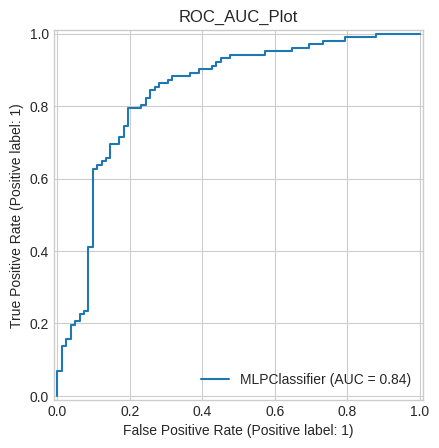

In [24]:
nn = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)
print("--- MLP ---")
model_train(nn)

--- Logistic Regression ---
Accuracy: 0.8696
Precision: 0.8611
Recall: 0.9118
Cross Validation Score :  0.9135
ROC_AUC Score :  0.8644


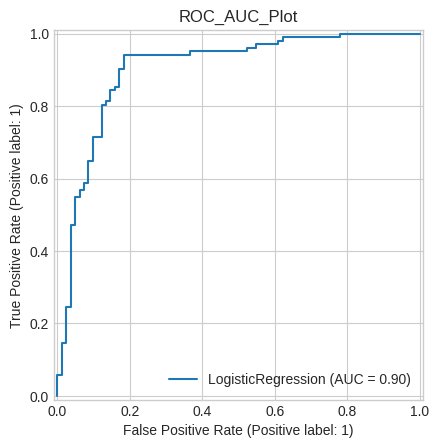

In [25]:
lr = LogisticRegression(random_state=42, max_iter=1000)
print("--- Logistic Regression ---")
model_train(lr)

--- XGBoost ---
Accuracy: 0.8967
Precision: 0.9029
Recall: 0.9118
Cross Validation Score :  0.9238
ROC_AUC Score :  0.8949


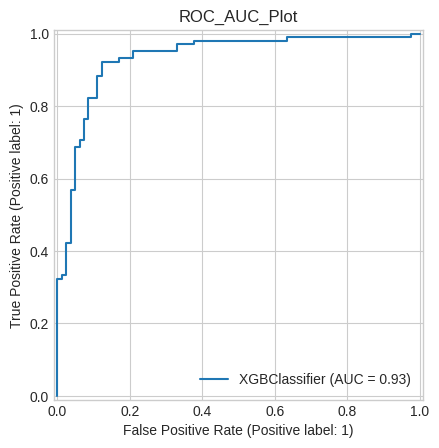

In [26]:
xgb_model = XGBClassifier(
                          random_state=42,
                          use_label_encoder=False, 
                          eval_metric='logloss',
                          n_estimators=120,
                          learning_rate=0.1,
                          max_depth=3,
                          max_leaves=4,
                          reg_alpha=0.5,
                          reg_lambda=1,
                         )
print("--- XGBoost ---")
model_train(xgb_model)

--- SVM ---
Accuracy: 0.8478
Precision: 0.8491
Recall: 0.8824
Cross Validation Score :  0.9077
ROC_AUC Score :  0.8436


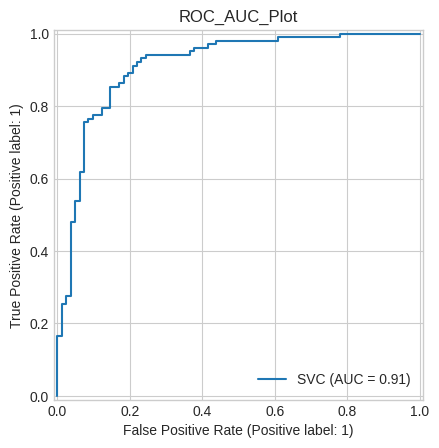

In [27]:
svm_model = SVC(kernel='rbf', random_state=42)
print("--- SVM ---")
model_train(svm_model)